<a href="https://colab.research.google.com/github/Kishor911/NNDL-Lab/blob/main/P_6(NNDL).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.callbacks import EarlyStopping


## Problem Statement and Steps

**Problem Statement:** An industrial IoT system continuously collects sensor readings from a machine. Detecting abnormal machine behavior manually from a large volume of sequential sensor data is difficult and time-consuming. Develop an LSTM-based autoencoder that learns normal sequential patterns and reconstructs the input sequence. The reconstruction error can be used to identify unusual patterns in the time-series data.

**Steps:**

1.  **Import libraries** (Done)
2.  Generate or load sequential timeseries data
3.  Preprocess the data
4.  Create input sequence
5.  Build LSTM model
6.  Compile & train
7.  Reconstruct the input sequence
8.  Calculate reconstruction error
9.  Visualize original & reconstructed sequence
10. Evaluate the model

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
df = pd.read_csv('/content/data_date.csv')
display(df.head())

,Date,Country,Status,AQI Value
0,2022-07-21,Albania,Good,14
1,2022-07-21,Algeria,Moderate,65
2,2022-07-21,Andorra,Moderate,55
3,2022-07-21,Angola,Unhealthy for Sensitive Groups,113
4,2022-07-21,Argentina,Moderate,63


In [ ]:
# Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# Sort data by Date (important for time series)
df = df.sort_values(by='Date').reset_index(drop=True)

# Check for missing values
print('Missing values before preprocessing:')
print(df.isnull().sum())

# For simplicity, we'll focus on 'AQI Value' for the autoencoder
# If there were missing values, common strategies include interpolation or removal.
# For now, let's assume 'AQI Value' is clean or will be handled by scaling.

# Select the feature for the autoencoder
data = df[['AQI Value']]

# Scale the data to a range between 0 and 1
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

print('\nData after scaling (first 5 rows):')
print(data_scaled[:5])

Missing values before preprocessing:
Date         0
Country      0
Status       0
AQI Value    0
dtype: int64

Data after scaling (first 5 rows):
[[0.01351351]
 [0.08212058]
 [0.01559252]
 [0.16632017]
 [0.02494802]]


In [ ]:
def create_sequences(data, timesteps):
    X = []
    for i in range(len(data) - timesteps):
        X.append(data[i:(i + timesteps), 0])
    return np.array(X)

# Define the number of timesteps (lookback period)
timesteps = 30  # This can be tuned

# Create sequences for the scaled AQI data
X = create_sequences(data_scaled, timesteps)

# Reshape data for LSTM input: (samples, timesteps, features)
# Since we have only one feature ('AQI Value'), the last dimension is 1.
X = X.reshape(X.shape[0], X.shape[1], 1)

print(f"Shape of input sequences: {X.shape}")
print("First sequence example:")
print(X[0])

Shape of input sequences: (26747, 30, 1)
First sequence example:
[[0.01351351]
 [0.08212058]
 [0.01559252]
 [0.16632017]
 [0.02494802]
 [0.07484407]
 [0.01247401]
 [0.13305613]
 [0.004158  ]
 [0.04158004]
 [0.08108108]
 [0.11642412]
 [0.03430353]
 [0.03222453]
 [0.002079  ]
 [0.00623701]
 [0.        ]
 [0.05405405]
 [0.02806653]
 [0.09147609]
 [0.03014553]
 [0.12266112]
 [0.11538462]
 [0.01455301]
 [0.08835759]
 [0.2006237 ]
 [0.0956341 ]
 [0.16735967]
 [0.00831601]
 [0.05925156]]


In [ ]:
# Define the Autoencoder model
def create_lstm_autoencoder(timesteps, n_features, latent_dim=16):
    # Encoder
    inputs = Input(shape=(timesteps, n_features))
    encoder = LSTM(latent_dim, activation='relu', return_sequences=False)(inputs)

    # Decoder
    decoder = RepeatVector(timesteps)(encoder)
    decoder = LSTM(latent_dim, activation='relu', return_sequences=True)(decoder)
    output = TimeDistributed(Dense(n_features))(decoder)

    model = Model(inputs=inputs, outputs=output)
    return model

# Get the number of features (should be 1 for 'AQI Value')
n_features = X.shape[2]

# Create the model
model = create_lstm_autoencoder(timesteps, n_features)

# Compile the model
model.compile(optimizer='adam', loss='mae')

# Print model summary
print(model.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 16)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 30, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 16)         │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 30, 1)          │            17 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,281 (12.82 KB)

 Trainable params: 3,281 (12.82 KB)

 Non-trainable params: 0 (0.00 B)

None


Shape of training sequences: (21397, 30, 1)
Shape of validation sequences: (5350, 30, 1)
Epoch 1/50
669/669 ━━━━━━━━━━━━━━━━━━━━ 19s 22ms/step - loss: 0.0350 - val_loss: 0.0342
Epoch 2/50
669/669 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - loss: 0.0341 - val_loss: 0.0340
Epoch 3/50
669/669 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - loss: 0.0340 - val_loss: 0.0340
Epoch 4/50
669/669 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - loss: 0.0338 - val_loss: 0.0335
Epoch 5/50
669/669 ━━━━━━━━━━━━━━━━━━━━ 16s 24ms/step - loss: 0.0334 - val_loss: 0.0333
Epoch 6/50
669/669 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - loss: 0.0332 - val_loss: 0.0330
Epoch 7/50
669/669 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - loss: 0.0329 - val_loss: 0.0328
Epoch 8/50
669/669 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - loss: 0.0327 - val_loss: 0.0326
Epoch 9/50
669/669 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - loss: 0.0326 - val_loss: 0.0326
Epoch 10/50
669/669 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - loss: 0.0325 - val_loss: 0.0325
Epoch 11/50
669/669 ━━━━━━━━━━

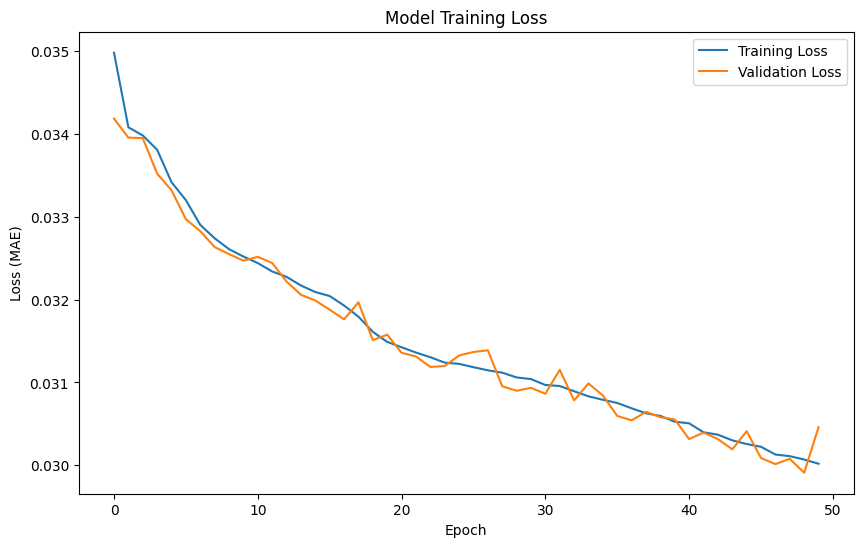

In [ ]:
# Split data into training and validation sets
X_train, X_val = train_test_split(X, test_size=0.2, random_state=42)

print(f"Shape of training sequences: {X_train.shape}")
print(f"Shape of validation sequences: {X_val.shape}")

# Define EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    mode='min',
    restore_best_weights=True
)

# Train the model
history = model.fit(
    X_train, X_train, # Autoencoder trains to reconstruct its input
    epochs=50, # You might increase this for better performance
    batch_size=32,
    validation_data=(X_val, X_val),
    callbacks=[early_stopping],
    verbose=1
)

# Plot training history (loss over epochs)
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Training Loss')
plt.ylabel('Loss (MAE)')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [ ]:
# Reconstruct the input sequences
X_reconstructed = model.predict(X)

# Calculate reconstruction error for each sequence
# We'll use Mean Absolute Error (MAE) as our error metric
reconstruction_errors = np.mean(np.abs(X - X_reconstructed), axis=(1, 2))

print(f"Shape of reconstructed sequences: {X_reconstructed.shape}")
print(f"Shape of reconstruction errors: {reconstruction_errors.shape}")
print("First 5 reconstruction errors:")
print(reconstruction_errors[:5])

836/836 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step
Shape of reconstructed sequences: (26747, 30, 1)
Shape of reconstruction errors: (26747,)
First 5 reconstruction errors:
[0.0368001  0.03874315 0.03625762 0.03645719 0.03941028]


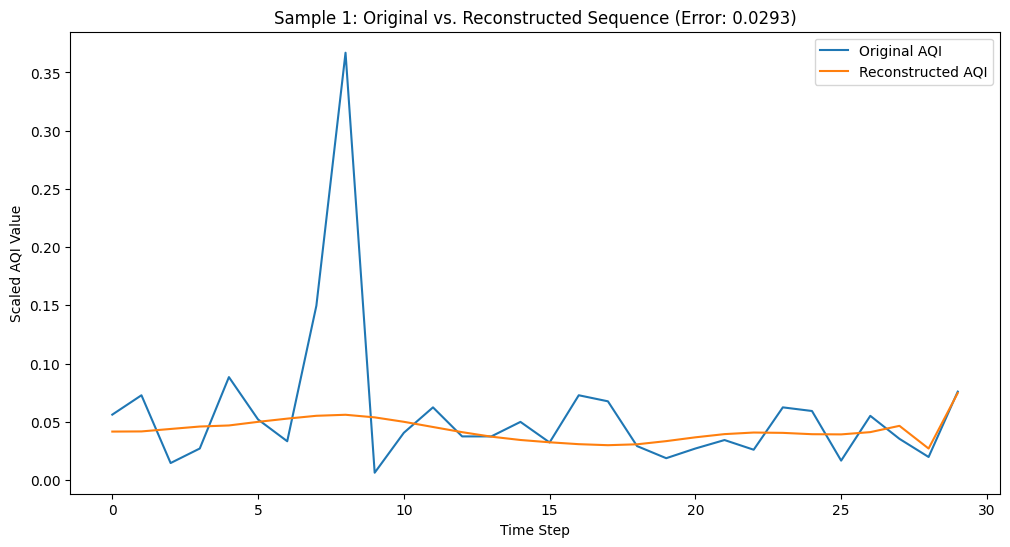

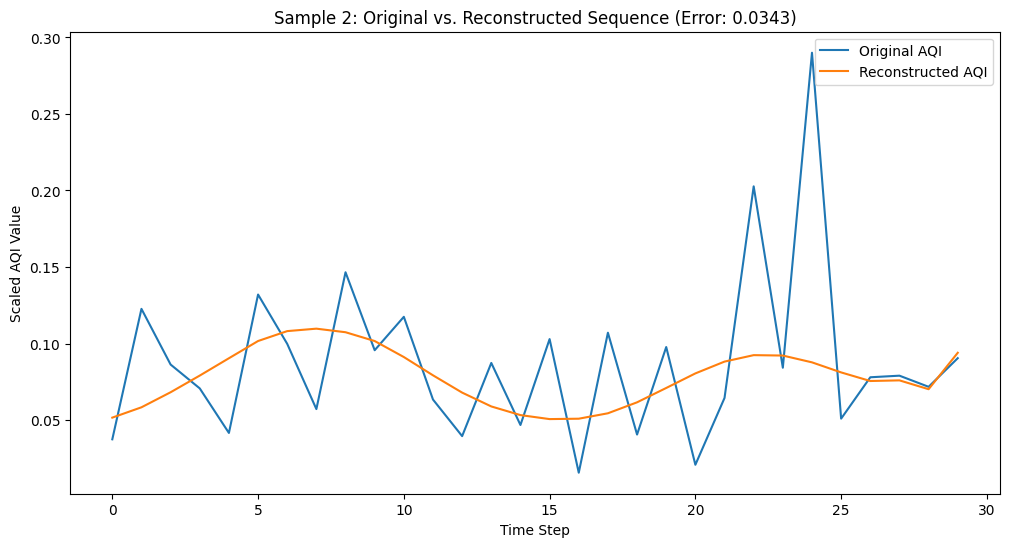

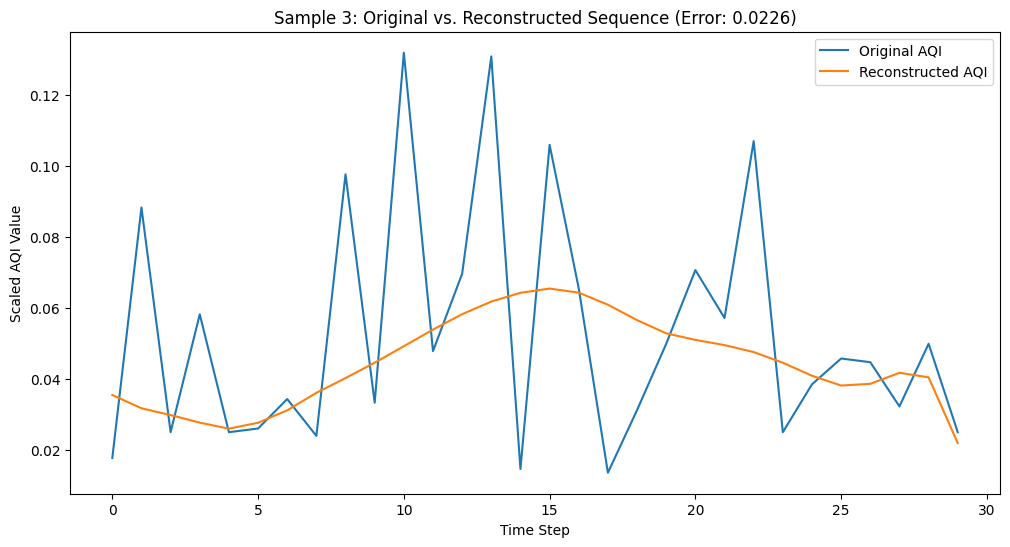

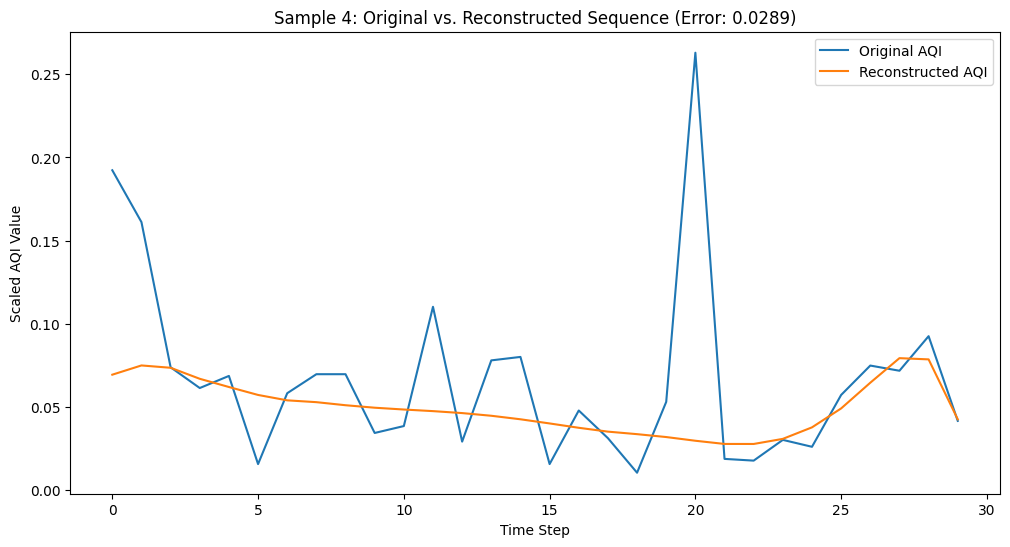

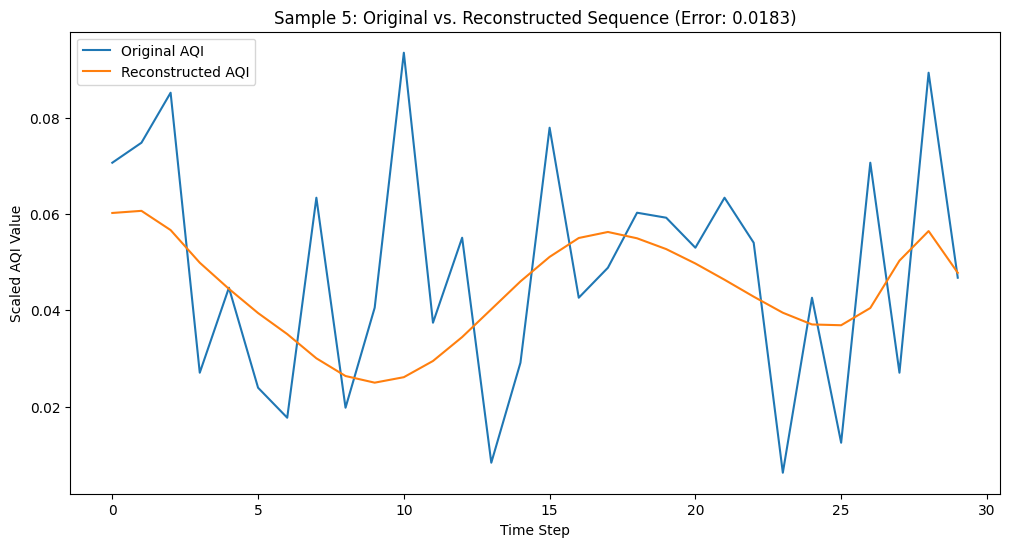

In [ ]:
# Function to plot original and reconstructed sequences
def plot_reconstruction(original, reconstructed, index, title='Original vs. Reconstructed Sequence'):
    plt.figure(figsize=(12, 6))
    plt.plot(original[index, :, 0], label='Original AQI')
    plt.plot(reconstructed[index, :, 0], label='Reconstructed AQI')
    plt.title(title)
    plt.xlabel('Time Step')
    plt.ylabel('Scaled AQI Value')
    plt.legend()
    plt.show()

# Plot a few random sequences to visualize reconstruction
num_plots = 5
random_indices = np.random.choice(len(X), num_plots, replace=False)

for i, idx in enumerate(random_indices):
    plot_reconstruction(X, X_reconstructed, idx, title=f'Sample {i+1}: Original vs. Reconstructed Sequence (Error: {reconstruction_errors[idx]:.4f})')

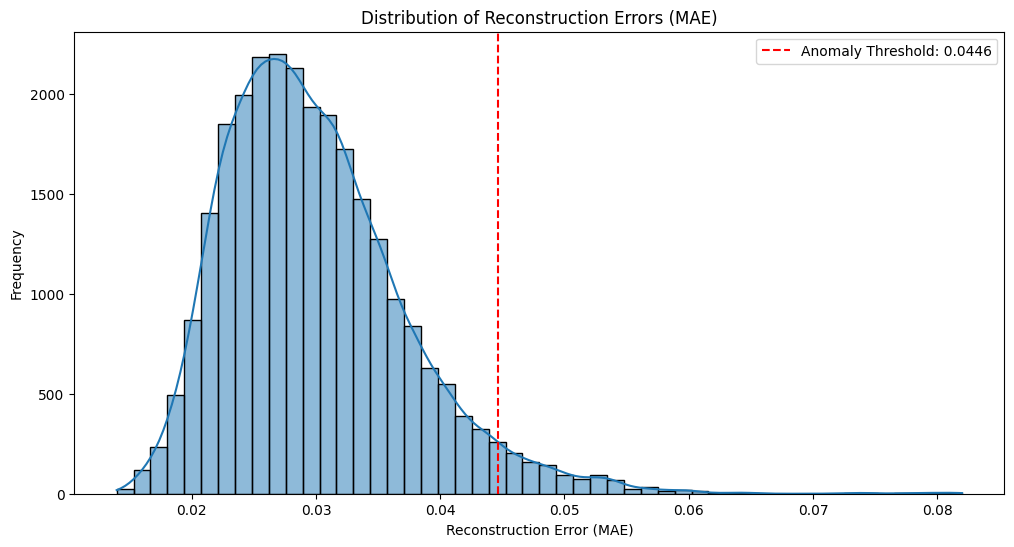

Anomaly Threshold: 0.0446
Number of anomalies detected: 1074


In [ ]:
# Plot the distribution of reconstruction errors
plt.figure(figsize=(12, 6))
sns.histplot(reconstruction_errors, bins=50, kde=True)
plt.title('Distribution of Reconstruction Errors (MAE)')
plt.xlabel('Reconstruction Error (MAE)')
plt.ylabel('Frequency')

# Define a threshold for anomaly detection
# A common approach is to use a percentile or mean + std deviation
threshold = np.mean(reconstruction_errors) + 2 * np.std(reconstruction_errors) # Example: mean + 2 standard deviations
# Alternatively, you can use a percentile:
# threshold = np.percentile(reconstruction_errors, 95) # e.g., 95th percentile

plt.axvline(threshold, color='r', linestyle='--', label=f'Anomaly Threshold: {threshold:.4f}')
plt.legend()
plt.show()

print(f"Anomaly Threshold: {threshold:.4f}")

# Identify anomalies
anomalies = reconstruction_errors > threshold
print(f"Number of anomalies detected: {np.sum(anomalies)}")

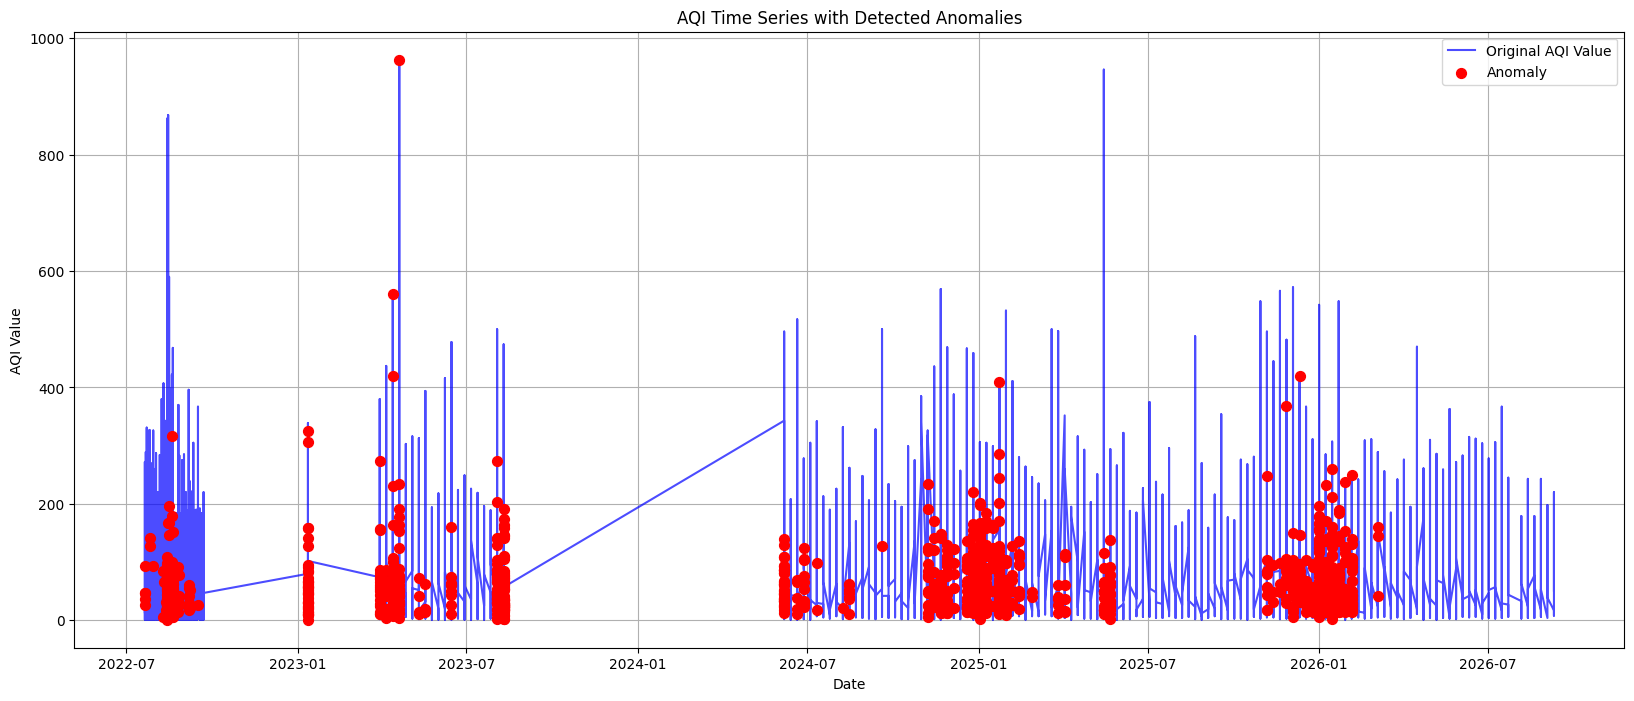

Anomaly detection process complete. Anomalies highlighted in the plot above.


In [ ]:
# To align anomalies with original data, we need to consider the `timesteps` offset.
# The reconstruction_errors array has a length of len(data) - timesteps.
# So, the anomalies correspond to the data points starting from index `timesteps`.

# Create an array to store anomaly flags for the original `data` length
anomaly_flags = np.zeros(len(data))

# Assign anomaly flags where anomalies were detected in the sequences
anomaly_flags[timesteps:] = anomalies

# Add reconstruction errors and anomaly flags to the original DataFrame for better visualization
# Note: errors are for sequences, so aligning them with the exact point might require careful indexing.
# For simplicity, we'll associate the error of a sequence with its last point.

df_results = df.copy()
df_results['reconstruction_error'] = np.nan # Initialize with NaN
df_results['is_anomaly'] = False # Initialize with False

# Fill in the reconstruction errors and anomaly flags
# The (i + timesteps - 1) index corresponds to the last point of the i-th sequence.
# This aligns the error of a sequence with the end of that sequence in the original time series.
for i in range(len(reconstruction_errors)):
    df_results.loc[timesteps + i, 'reconstruction_error'] = reconstruction_errors[i]
    df_results.loc[timesteps + i, 'is_anomaly'] = anomalies[i]

# Visualize the original AQI time series with anomalies highlighted
plt.figure(figsize=(20, 8))
plt.plot(df_results['Date'], df_results['AQI Value'], label='Original AQI Value', color='blue', alpha=0.7)

# Highlight anomalies
anomalous_points = df_results[df_results['is_anomaly'] == True]
plt.scatter(anomalous_points['Date'], anomalous_points['AQI Value'], color='red', label='Anomaly', s=50, zorder=5)

plt.title('AQI Time Series with Detected Anomalies')
plt.xlabel('Date')
plt.ylabel('AQI Value')
plt.legend()
plt.grid(True)
plt.show()

print("Anomaly detection process complete. Anomalies highlighted in the plot above.")